<a href="https://colab.research.google.com/github/springboardmentor1234x-stack/CNN-Music-Instrument-Recognition/blob/KaaviyaaShree/instrument_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install librosa

In [2]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as ply

In [3]:
!wget http://download.magenta.tensorflow.org/datasets/nsynth/nsynth-test.jsonwav.tar.gz

--2026-03-01 13:39:10--  http://download.magenta.tensorflow.org/datasets/nsynth/nsynth-test.jsonwav.tar.gz
Resolving download.magenta.tensorflow.org (download.magenta.tensorflow.org)... 74.125.26.207, 173.194.216.207, 172.217.204.207, ...
Connecting to download.magenta.tensorflow.org (download.magenta.tensorflow.org)|74.125.26.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 349501546 (333M) [application/gzip]
Saving to: ‘nsynth-test.jsonwav.tar.gz’

nsynth-test.jsonwav 100%[===================>] 333.31M   101MB/s    in 3.3s    

2026-03-01 13:39:14 (101 MB/s) - ‘nsynth-test.jsonwav.tar.gz’ saved [349501546/349501546]



In [4]:
!tar -xzf nsynth-test.jsonwav.tar.gz

In [5]:
import os

audio_path = "nsynth-test/audio"
print("Number of audio files:", len(os.listdir(audio_path)))

Number of audio files: 4096


In [6]:
import json

with open("nsynth-test/examples.json") as f:
    metadata = json.load(f)

print("Total metadata entries:", len(metadata))

# Print one example
first_key = list(metadata.keys())[0]
print("Example key:", first_key)
print("Metadata for that file:")
print(metadata[first_key])

Total metadata entries: 4096
Example key: bass_synthetic_068-049-025
Metadata for that file:
{'qualities': [0, 1, 0, 0, 0, 0, 0, 0, 0, 0], 'pitch': 49, 'note': 217499, 'instrument_source_str': 'synthetic', 'velocity': 25, 'instrument_str': 'bass_synthetic_068', 'instrument': 656, 'sample_rate': 16000, 'qualities_str': ['dark'], 'instrument_source': 2, 'note_str': 'bass_synthetic_068-049-025', 'instrument_family': 0, 'instrument_family_str': 'bass'}


In [7]:
families = set()

for key in metadata:
    families.add(metadata[key]['instrument_family_str'])

print("Instrument Families:")
print(sorted(families))

Instrument Families:
['bass', 'brass', 'flute', 'guitar', 'keyboard', 'mallet', 'organ', 'reed', 'string', 'vocal']


In [8]:
selected_families = ['guitar', 'keyboard', 'bass', 'flute', 'string']
mini_dataset = []

for key in metadata:
    family = metadata[key]['instrument_family_str']

    if family in selected_families:
        mini_dataset.append((key, family))

from collections import defaultdict

limited_dataset = defaultdict(list)

for key, family in mini_dataset:
    if len(limited_dataset[family]) < 50:  # limit 50 per instrument
        limited_dataset[family].append(key)

# Check counts
total = sum(len(v) for v in limited_dataset.values())

print("Samples per instrument:")
for family in limited_dataset:
    print(family, ":", len(limited_dataset[family]))

print("Total samples:", total)

Samples per instrument:
bass : 50
keyboard : 50
guitar : 50
flute : 50
string : 50
Total samples: 250


In [9]:
import os
import shutil

# Base folder
base_dir = "mini_nsynth"
os.makedirs(base_dir, exist_ok=True)

for family in limited_dataset:
    folder_path = os.path.join(base_dir, family)
    os.makedirs(folder_path, exist_ok=True)

    for key in limited_dataset[family]:
        src = os.path.join("nsynth-test/audio", key + ".wav")
        dst = os.path.join(folder_path, key + ".wav")
        shutil.copy(src, dst)

print("Mini NSynth dataset organized successfully!")

Mini NSynth dataset organized successfully!


File: mini_nsynth/guitar/guitar_acoustic_015-061-075.wav
Sampling rate: 16000
Waveform shape: (64000,)
Duration (seconds): 4.0


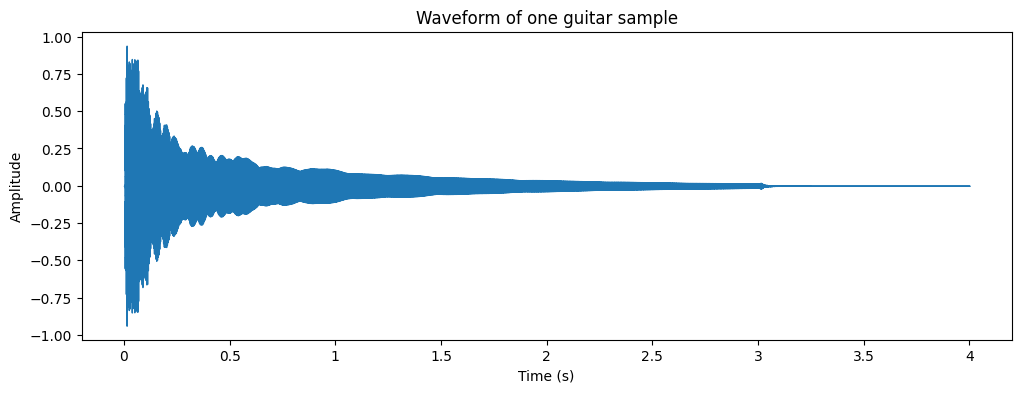

In [10]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os


# Pick one audio file (example: first guitar file)
audio_file = os.path.join("mini_nsynth", "guitar", os.listdir("mini_nsynth/guitar")[0])

# Load audio
y, sr = librosa.load(audio_file, sr=None)  # sr=None keeps original 16kHz

# Print basic info
print("File:", audio_file)
print("Sampling rate:", sr)
print("Waveform shape:", y.shape)
print("Duration (seconds):", len(y)/sr)

# Visualize waveform
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform of one guitar sample")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# Trimming the silence

In [11]:
import librosa.effects

y_trimmed, index = librosa.effects.trim(y, top_db=20)

print("Original waveform length:", len(y))
print("Trimmed waveform length:", len(y_trimmed))

Original waveform length: 64000
Trimmed waveform length: 27648


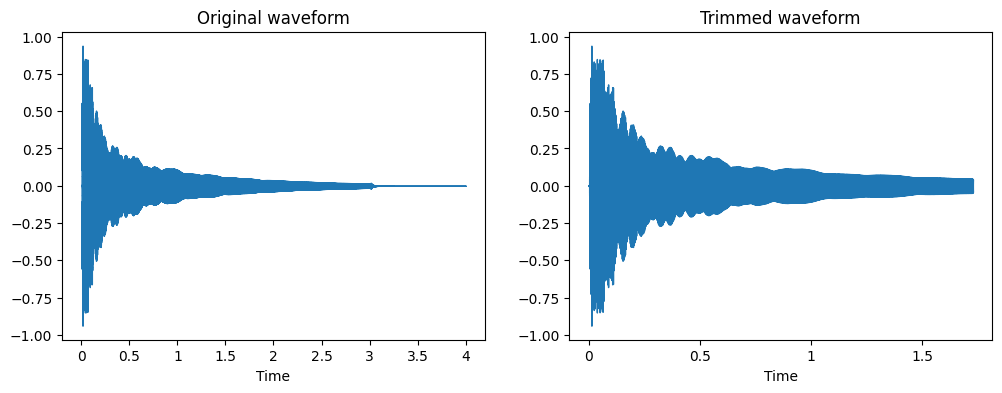

In [12]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
librosa.display.waveshow(y, sr=sr)
plt.title("Original waveform")
plt.subplot(1, 2, 2)
librosa.display.waveshow(y_trimmed, sr=sr)
plt.title("Trimmed waveform")
plt.show()

# Normalizing Amplitude

In [13]:
import numpy as np

# Peak normalization to [-1, 1] range
y_normalized = y_trimmed / np.max(np.abs(y_trimmed))

print("Max amplitude before:", np.max(np.abs(y_trimmed)))
print("Max amplitude after:", np.max(np.abs(y_normalized)))

Max amplitude before: 0.93899536
Max amplitude after: 1.0


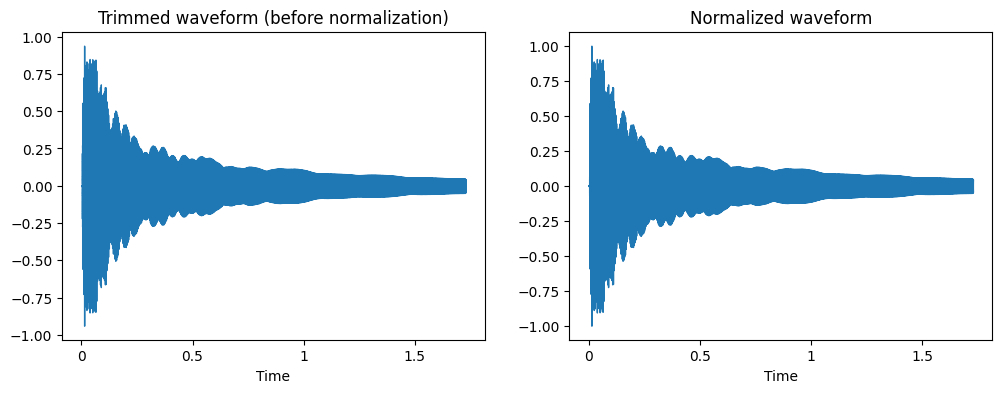

In [14]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
librosa.display.waveshow(y_trimmed, sr=sr)
plt.title("Trimmed waveform (before normalization)")
plt.subplot(1, 2, 2)
librosa.display.waveshow(y_normalized, sr=sr)
plt.title("Normalized waveform")
plt.show()

# STFT

In [15]:
D = librosa.stft(y_normalized, n_fft=1024, hop_length=512)

print("STFT shape:", D.shape)

STFT shape: (513, 55)


# Mel Scale

In [16]:
mel_spec = librosa.feature.melspectrogram(
    y=y_normalized,
    sr=sr,
    n_fft=1024,
    hop_length=512,
    n_mels=128
)

print("Mel Spectrogram shape:", mel_spec.shape)

Mel Spectrogram shape: (128, 55)


# Log Scale

In [17]:
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

print("Log Mel shape:", mel_spec_db.shape)
print("Min value:", mel_spec_db.min())
print("Max value:", mel_spec_db.max())

Log Mel shape: (128, 55)
Min value: -80.0
Max value: 0.0


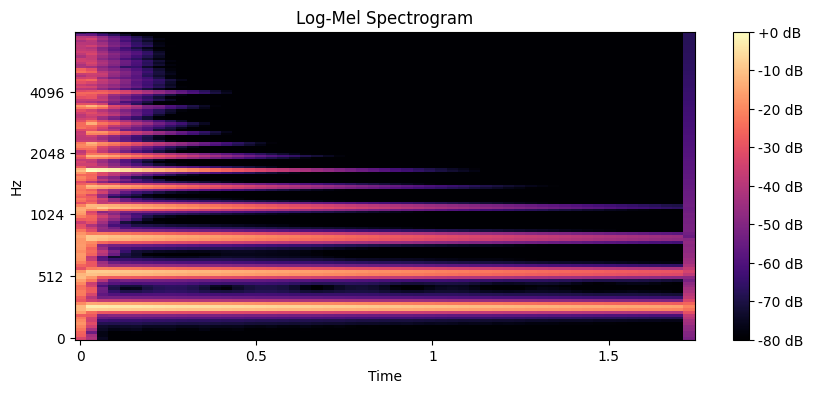

In [18]:
plt.figure(figsize=(10,4))
librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar(format="%+2.0f dB")
plt.title("Log-Mel Spectrogram")
plt.show()

In [19]:
mfcc = librosa.feature.mfcc(
    y=y_normalized,
    sr=sr,
    n_mfcc=13
)

print("MFCC shape:", mfcc.shape)

MFCC shape: (13, 55)


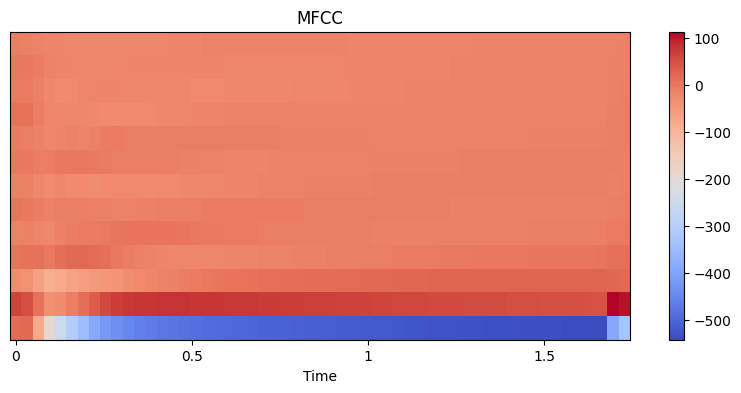

In [20]:
plt.figure(figsize=(10,4))
librosa.display.specshow(
    mfcc,
    x_axis='time',
    sr=sr
)
plt.colorbar()
plt.title("MFCC")
plt.show()

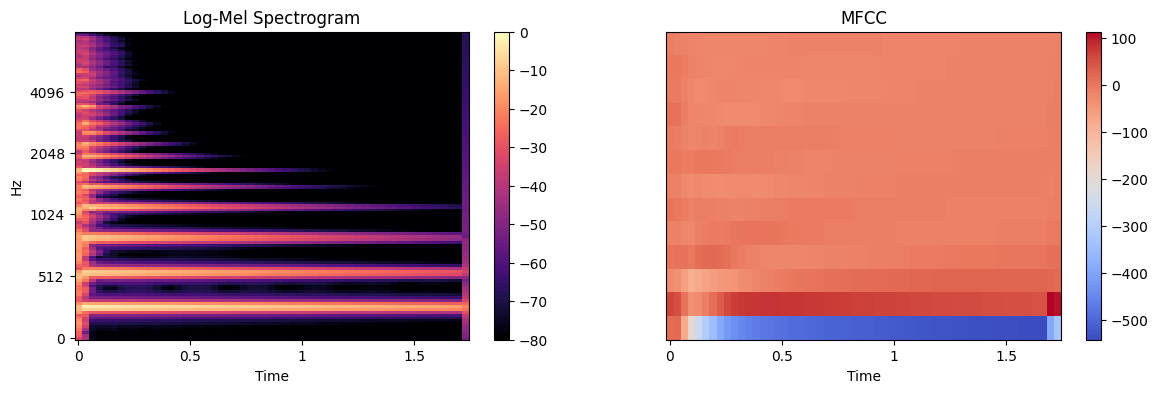

In [21]:
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='mel'
)
plt.title("Log-Mel Spectrogram")
plt.colorbar()

plt.subplot(1,2,2)
librosa.display.specshow(
    mfcc,
    sr=sr,
    x_axis='time'
)
plt.title("MFCC")
plt.colorbar()

plt.show()

**Observation**
# Shape Difference

Log-Mel Spectrogram shape: (128, T)

MFCC shape: (13, T)

# Visual Difference

The Log-Mel Spectrogram shows detailed frequency patterns across time. Harmonic structures and energy distributions across Mel bands are clearly visible.

The MFCC representation appears smoother and less detailed. Fine harmonic patterns are no longer visible.

In [22]:
label_map = {
    'guitar': 0,
    'keyboard': 1,
    'bass': 2,
    'flute': 3,
    'string': 4
}

In [23]:
X = []
y = []

In [24]:
import os
import librosa
import numpy as np

base_path = "mini_nsynth"

for instrument in os.listdir(base_path):

    instrument_path = os.path.join(base_path, instrument)

    for file in os.listdir(instrument_path):

        file_path = os.path.join(instrument_path, file)

        # Load audio
        signal, sr = librosa.load(file_path, sr=16000)

        # Normalize
        signal = signal / np.max(np.abs(signal))

        # Create Mel Spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=signal,
            sr=sr,
            n_fft=1024,
            hop_length=512,
            n_mels=128
        )

        # Convert to Log scale
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # Append to dataset
        X.append(mel_spec_db)
        y.append(label_map[instrument])

In [25]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (250, 128, 126)
y shape: (250,)


In [26]:
X = X[..., np.newaxis]

print("New X shape:", X.shape)

New X shape: (250, 128, 126, 1)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # VERY IMPORTANT
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (200, 128, 126, 1)
X_val shape: (50, 128, 126, 1)


In [28]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=5)
y_val = to_categorical(y_val, num_classes=5)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

y_train shape: (200, 5)
y_val shape: (50, 5)


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# First Convolution Block
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,126,1)))
model.add(MaxPooling2D((2,2)))

# Second Convolution Block
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(5, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 124, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,605 (14.14 MB)

 Trainable params: 3,705,605 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=16
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 363ms/step - accuracy: 0.1314 - loss: 103.4225 - val_accuracy: 0.2000 - val_loss: 1.9099
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 337ms/step - accuracy: 0.2354 - loss: 1.8040 - val_accuracy: 0.2000 - val_loss: 1.6061
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 422ms/step - accuracy: 0.4624 - loss: 1.5387 - val_accuracy: 0.2600 - val_loss: 1.5985
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 333ms/step - accuracy: 0.4951 - loss: 1.4053 - val_accuracy: 0.3800 - val_loss: 1.6906
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 382ms/step - accuracy: 0.5482 - loss: 1.1220 - val_accuracy: 0.4000 - val_loss: 1.6900
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 372ms/step - accuracy: 0.6514 - loss: 0.9237 - val_accuracy: 0.4600 - val_loss: 1.2892
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 327ms/step - accuracy: 0.7200 - loss: 0.6768 - val_accuracy: 0.5200 - val_loss: 1.2245
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 456ms/step - accuracy: 0.8253 - loss: 0.4582 - val_accuracy: 

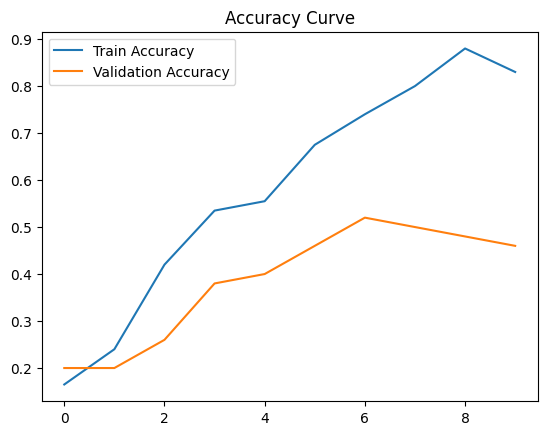

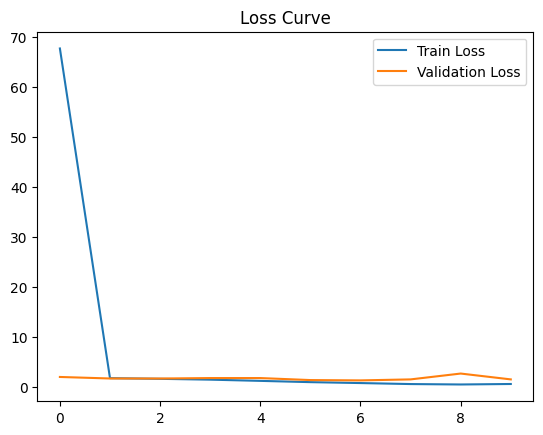

In [32]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

In [33]:
from sklearn.metrics import classification_report
import numpy as np

# Predict on validation set
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert one-hot y_val back to integer
y_true = np.argmax(y_val, axis=1)

print(classification_report(y_true, y_pred, target_names=['guitar','keyboard','bass','flute','string']))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 399ms/step
              precision    recall  f1-score   support

      guitar       0.36      0.50      0.42        10
    keyboard       0.27      0.30      0.29        10
        bass       0.60      0.30      0.40        10
       flute       0.50      0.40      0.44        10
      string       0.67      0.80      0.73        10

    accuracy                           0.46        50
   macro avg       0.48      0.46      0.45        50
weighted avg       0.48      0.46      0.45        50



In [34]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [35]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [36]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,   # we allow more, early stopping will stop automatically
    batch_size=16,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.8914 - loss: 0.3435

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 361ms/step - accuracy: 0.8924 - loss: 0.3414 - val_accuracy: 0.5400 - val_loss: 1.5247 - learning_rate: 0.0010
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 455ms/step - accuracy: 0.9269 - loss: 0.2655 - val_accuracy: 0.6000 - val_loss: 1.5274 - learning_rate: 0.0010
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.9254 - loss: 0.2754

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 350ms/step - accuracy: 0.9250 - loss: 0.2761 - val_accuracy: 0.5000 - val_loss: 1.5054 - learning_rate: 0.0010
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 378ms/step - accuracy: 0.8589 - loss: 0.4855 - val_accuracy: 0.4800 - val_loss: 1.6905 - learning_rate: 0.0010
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.9417 - loss: 0.1962

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 406ms/step - accuracy: 0.9405 - loss: 0.2007 - val_accuracy: 0.6000 - val_loss: 1.5027 - learning_rate: 0.0010
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 322ms/step - accuracy: 0.9453 - loss: 0.1859 - val_accuracy: 0.6400 - val_loss: 1.5517 - learning_rate: 0.0010
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.9053 - loss: 0.2373
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 440ms/step - accuracy: 0.9077 - loss: 0.2347 - val_accuracy: 0.6200 - val_loss: 1.6811 - learning_rate: 0.0010
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 331ms/step - accuracy: 0.9518 - loss: 0.1554 - val_accuracy: 0.6000 - val_loss: 1.5961 - learning_rate: 5.0000e-04


In [37]:
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)

from sklearn.metrics import classification_report
print(classification_report(
    y_true,
    y_pred,
    target_names=['guitar','keyboard','bass','flute','string']
))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step
              precision    recall  f1-score   support

      guitar       0.38      0.50      0.43        10
    keyboard       0.36      0.50      0.42        10
        bass       1.00      0.50      0.67        10
       flute       0.78      0.70      0.74        10
      string       0.89      0.80      0.84        10

    accuracy                           0.60        50
   macro avg       0.68      0.60      0.62        50
weighted avg       0.68      0.60      0.62        50



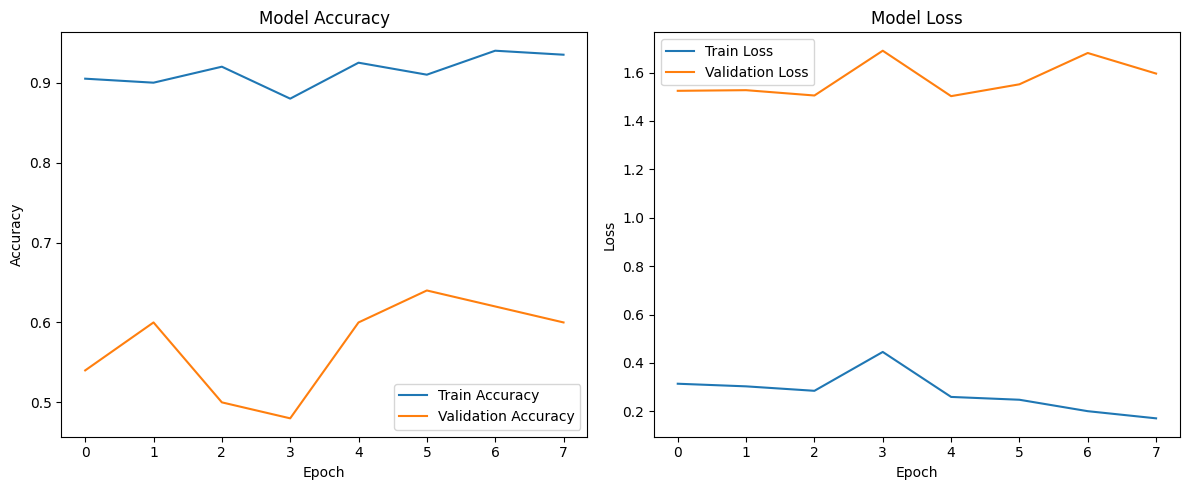

In [38]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()